# Autoregressive Conditional Heteroskedasticity (ARCH)
- periods of high volatility are followed by periods of even higher volatility
- periods of low volatility are followed by periods of even lower volatility

In practice this means that volatility tends to cluster.

## GARCH
- error varince is thought to be autocorrelated over time
- assume the variance of the error term follows a process based on an autoregressive moving average
- supposed to capture better long-term volatility patterns

## ARCH(q) == GARCH(0, q)

In [28]:
import numpy as np
from arch import arch_model
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath('..'))
from functions import line_plot, mse, mae, rmse, mase, compute_daily_volatility

import warnings
warnings.filterwarnings("ignore")

from tqdm import tqdm

In [29]:
df = pd.read_csv('../Data/aluminium_pre_inputs.csv')

## Experiment 1:
GARCH(1, 1) model
- Next Day volatility calculation

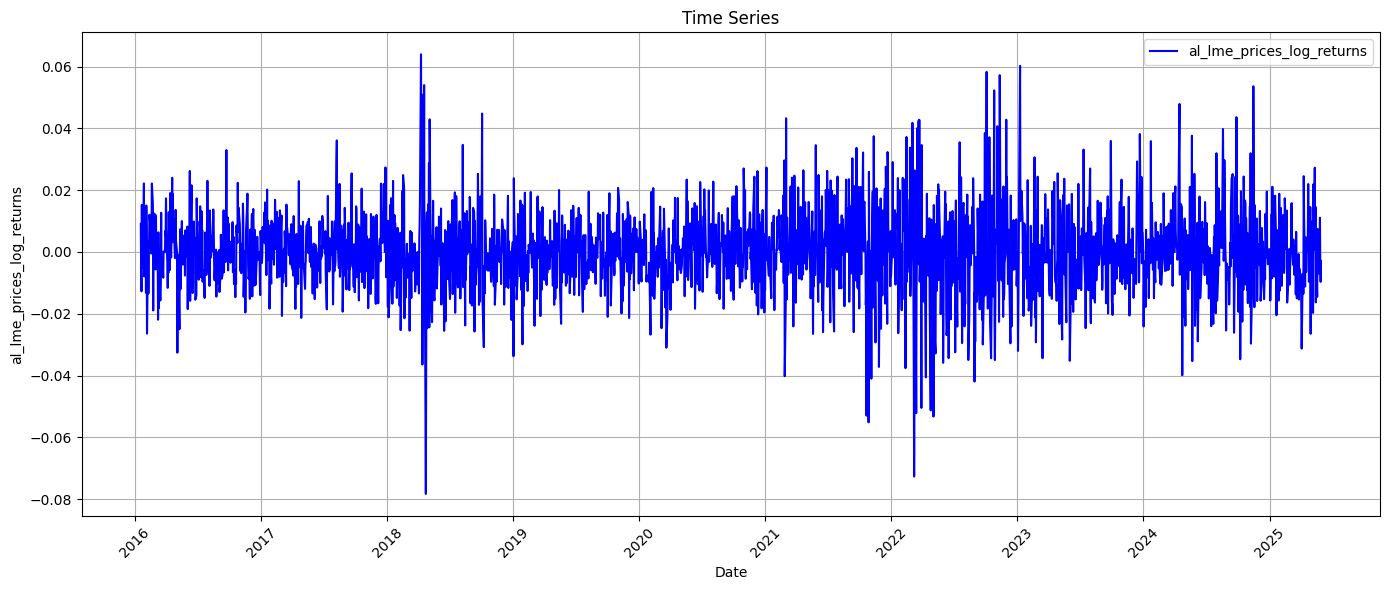

<Axes: title={'center': 'Time Series'}, xlabel='Date', ylabel='al_lme_prices_log_returns'>

In [3]:
line_plot(df['date'], df['al_lme_prices_log_returns'], 'al_lme_prices_log_returns')

In [37]:
vol = compute_daily_volatility(df['al_lme_prices_log_returns'], window=7, method='rolling')
vol
df['weekly'] = vol
df

,date,al_lme_prices_log_returns,al_lme_prices_daily_returns,us_dollar_index,canadian_dollar_spot,emirate_dirham_spot,russian_ruble_spot,nor_krone_spot,australian_dollar_spot,malaysian_ringgit_spot,...,china_300,china_gdp_agr,germany_gdp_agr,japan_gdp_agr,us_gdp_agr,china_caixin_pmi,germany_pmi,japan_pmi,us_pmi,weekly
0,1/18/2016,0.009106,0.009148,98.956,1.4561,3.6726,79.3775,8.8984,1.457089,4.3930,...,3130.7289,6.8,1.3,0.9,2.0,48.2,53.2,52.6,51.2,NaN
1,1/19/2016,-0.004711,-0.004700,98.991,1.4576,3.6723,78.7850,8.8061,1.448646,4.3625,...,3223.1251,6.8,1.3,0.9,2.0,48.2,53.2,52.6,51.2,NaN
2,1/20/2016,-0.012730,-0.012650,99.091,1.4501,3.6723,81.3475,8.8728,1.448016,4.3910,...,3174.3781,6.8,1.3,0.9,2.0,48.2,53.2,52.6,51.2,NaN
3,1/21/2016,0.015257,0.015374,99.056,1.4261,3.6722,82.3675,8.7823,1.429388,4.3730,...,3081.3454,6.8,1.3,0.9,2.0,48.2,53.2,52.6,51.2,NaN
4,1/22/2016,-0.002189,-0.002187,99.574,1.4115,3.6722,78.1000,8.7341,1.428571,4.2940,...,3113.4626,6.8,1.3,0.9,2.0,48.2,53.2,52.6,51.2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2440,5/26/2025,0.000000,0.000000,99.112,1.3735,3.6724,79.7500,10.0879,1.542496,4.2150,...,3860.1067,5.4,-0.2,1.7,2.0,50.4,48.4,48.7,50.2,0.007171
2441,5/27/2025,0.011054,0.011116,99.521,1.3809,3.6727,80.2455,10.1481,1.552072,4.2350,...,3860.1067,5.4,-0.2,1.7,2.0,50.4,48.4,48.7,50.2,0.008696
2442,5/28/2025,-0.006125,-0.006107,99.875,1.3833,3.6729,79.8705,10.1868,1.556178,4.2200,...,3836.2366,5.4,-0.2,1.7,2.0,50.4,48.4,48.7,50.2,0.006746
2443,5/29/2025,-0.009670,-0.009623,99.278,1.3808,3.6726,76.8955,10.1082,1.552554,4.2400,...,3858.6998,5.4,-0.2,1.7,2.0,50.4,48.4,48.7,50.2,0.007116


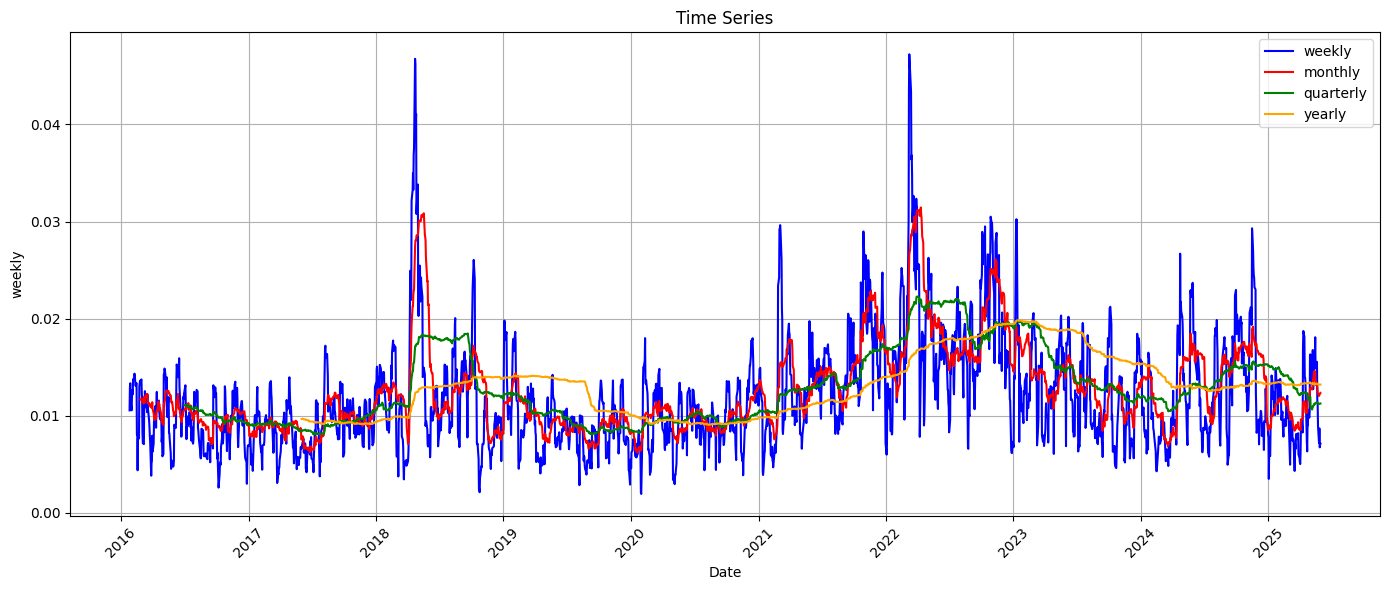

In [34]:
colors = ['blue', 'red', 'green', 'orange']
for i, (length, desc) in enumerate(zip([7, 30, 120, 360], ['weekly', 'monthly', 'quarterly', 'yearly'])):
    vol = compute_daily_volatility(df['al_lme_prices_log_returns'], window=length, method='rolling')
    if i == 0:
        ax = line_plot(df['date'], vol, ylabel=desc, linecolor=colors[i], show=False)
    elif i == 3:
        line_plot(df['date'], vol, ylabel=desc, linecolor=colors[i], ax=ax, show=True)
    else:
        line_plot(df['date'], vol, ylabel=desc, linecolor=colors[i], ax=ax, show=False)

ax.legend()
plt.tight_layout()
plt.show()

1/3


 10%|▉         | 241/2435 [00:02<00:24, 89.25it/s] c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 28%|██▊       | 681/2435 [00:06<00:16, 108.98it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 54%|█████▍    | 1322/2435 [00:13<00:10, 104.48it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The me

2/3


 19%|█▉        | 458/2415 [00:04<00:22, 86.28it/s] c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 45%|████▌     | 1089/2415 [00:11<00:11, 113.11it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
100%|██████████| 2415/2415 [00:25<00:00, 96.45it/s] 


3/3


 15%|█▍        | 341/2345 [00:03<00:20, 96.98it/s] c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 19%|█▉        | 442/2345 [00:04<00:16, 112.40it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 50%|████▉     | 1161/2345 [00:11<00:12, 92.63it/s] c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The me

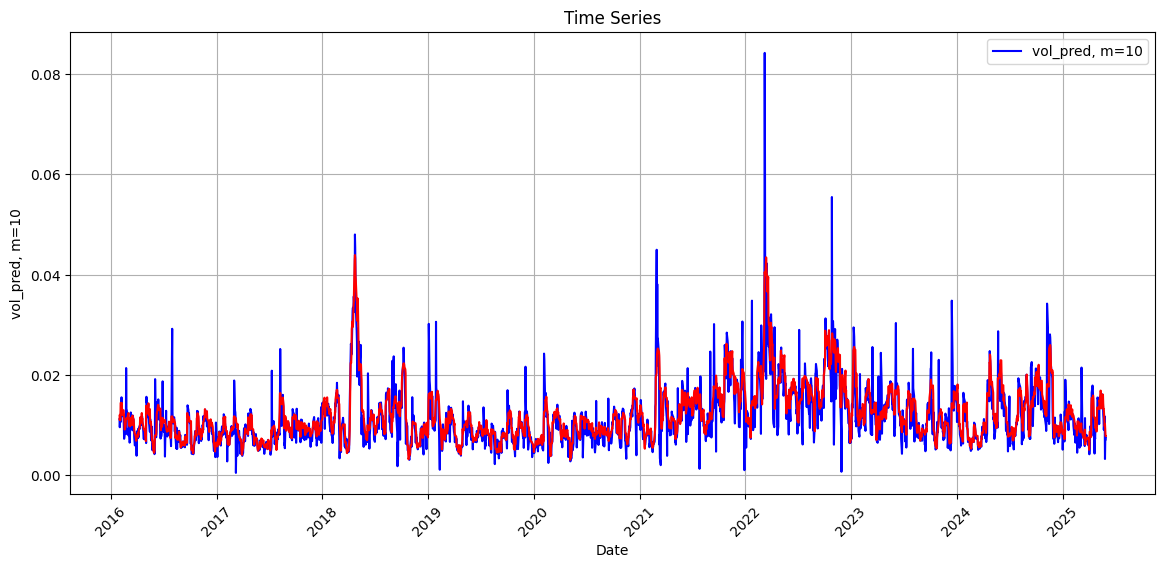

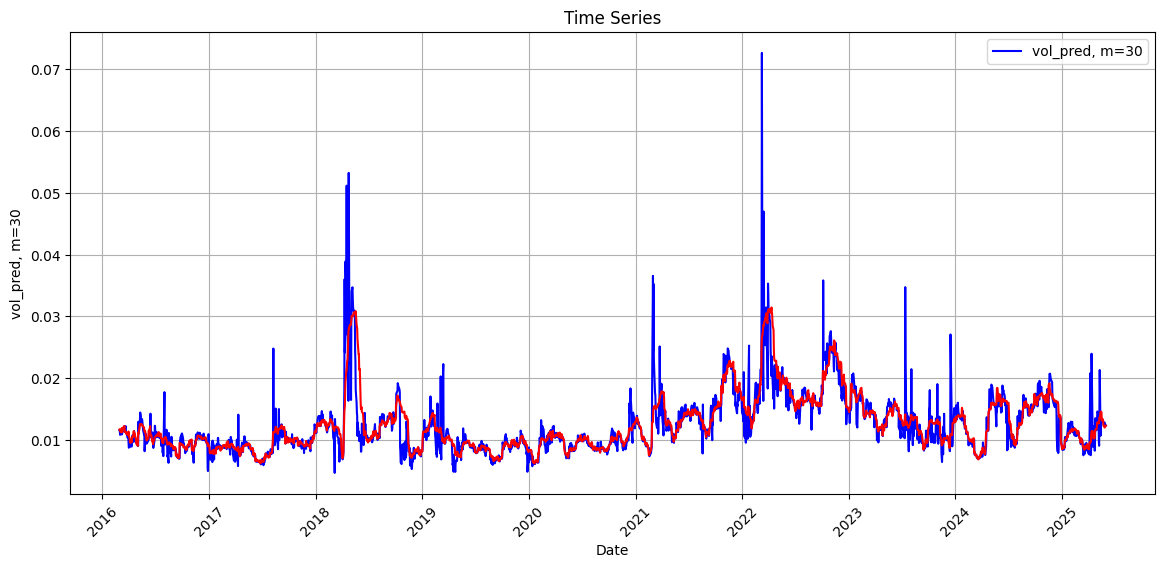

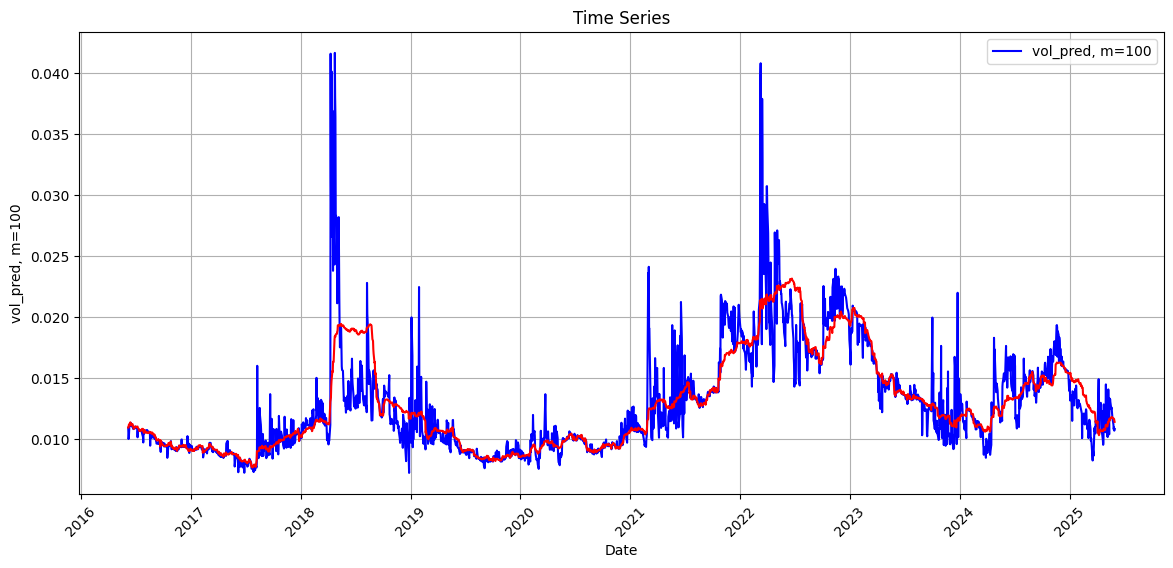

In [ ]:
context_window_vals = [10, 30, 100]
for i, context_window_length in enumerate(context_window_vals):
    print(f'{i+1}/{len(context_window_vals)}')
    vols_pred = [0]*context_window_length
    for i in tqdm(range(context_window_length, df.shape[0])):
        model = arch_model(df['al_lme_prices_log_returns'][i-context_window_length:i], vol='Garch', p=1, q=1, dist='normal', mean='constant', rescale=False)
        res = model.fit(disp='off')
        volatility = res.conditional_volatility
        forecast = res.forecast(horizon=1)
        next_volatility = np.sqrt(forecast.variance.values[-1 ,0])
        vols_pred.append(next_volatility)

    daily_vol = compute_daily_volatility(df['al_lme_prices_log_returns'], window=context_window_length, method='rolling')

    ax = line_plot(df['date'][context_window_length:], vols_pred[context_window_length:], f'vol_pred, m={context_window_length}',show=False)
    _ = line_plot(df['date'][context_window_length:], daily_vol[context_window_length:], 'vol_true', linecolor='red', ax=ax, show=True)

1/4


  8%|▊         | 195/2435 [00:04<00:52, 42.70it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 12%|█▏        | 287/2435 [00:05<00:40, 53.16it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 15%|█▌        | 367/2435 [00:07<00:33, 61.87it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The messag

2/4


  6%|▋         | 154/2415 [00:03<00:37, 60.01it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 12%|█▏        | 292/2415 [00:06<00:53, 39.94it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 18%|█▊        | 443/2415 [00:09<00:41, 48.00it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directio

3/4


  5%|▌         | 123/2345 [00:02<00:43, 51.62it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 10%|▉         | 231/2345 [00:04<00:26, 79.57it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 15%|█▍        | 344/2345 [00:06<00:56, 35.49it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The messag

4/4


 40%|████      | 904/2245 [00:17<00:26, 50.59it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 72%|███████▏  | 1621/2245 [00:33<00:11, 56.00it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 93%|█████████▎| 2086/2245 [00:41<00:03, 51.10it/s] c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 9. The mes

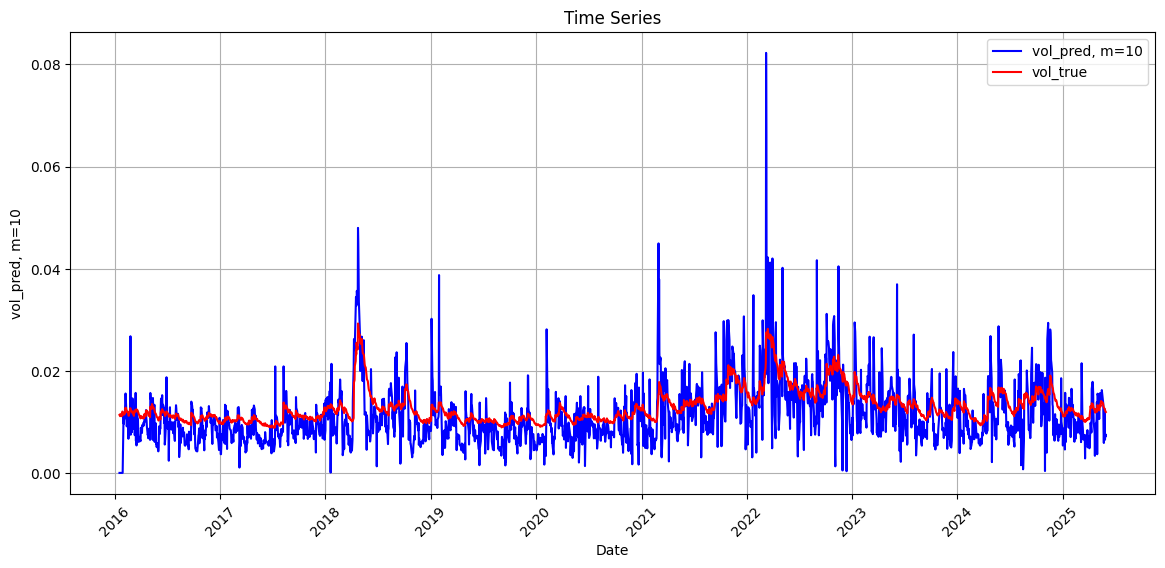

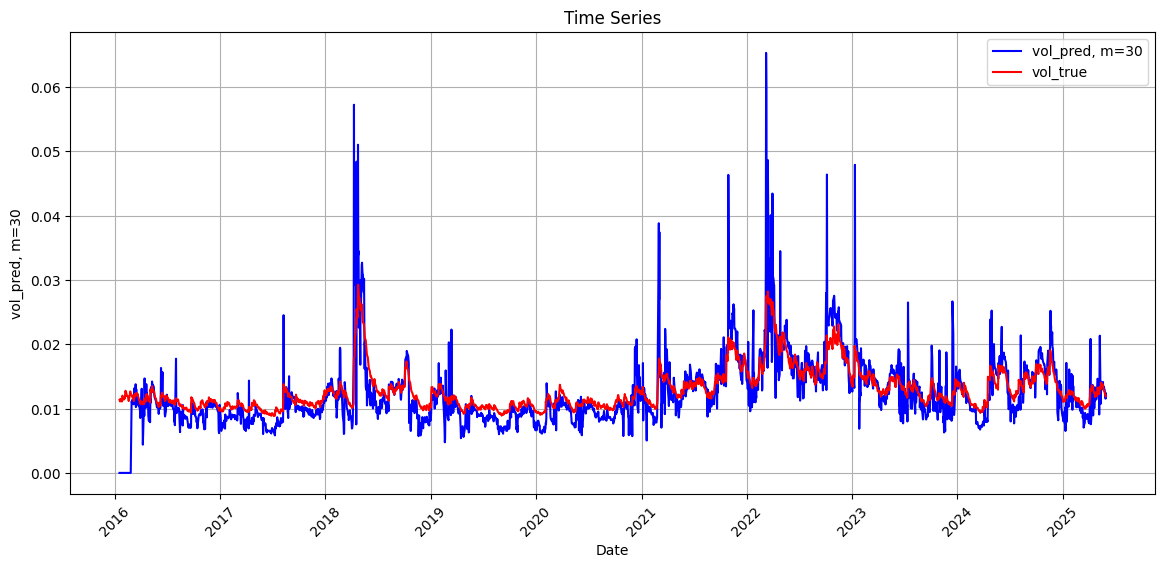

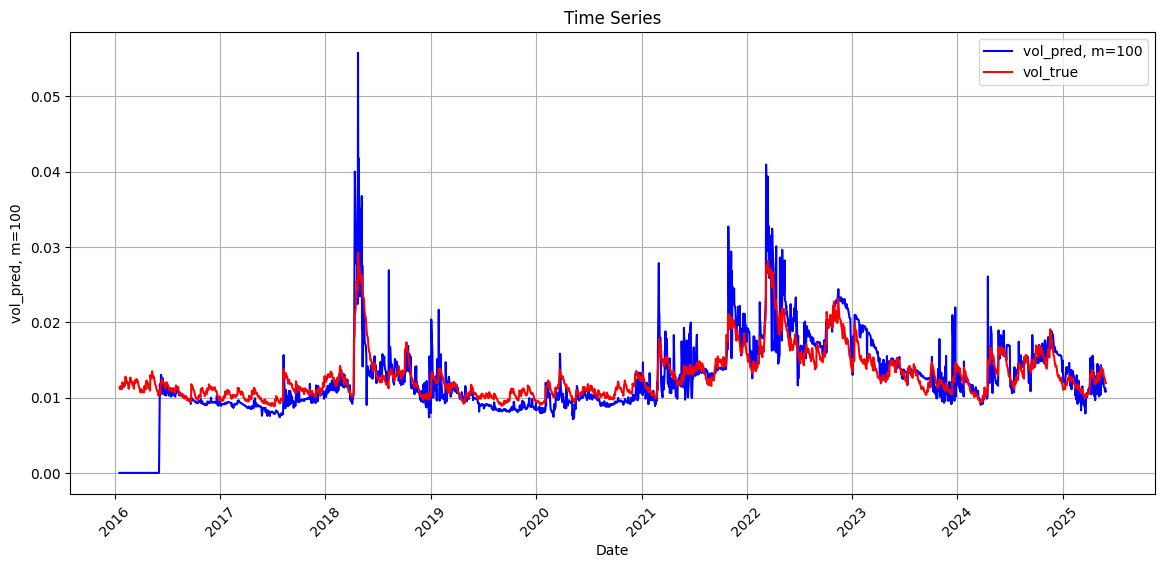

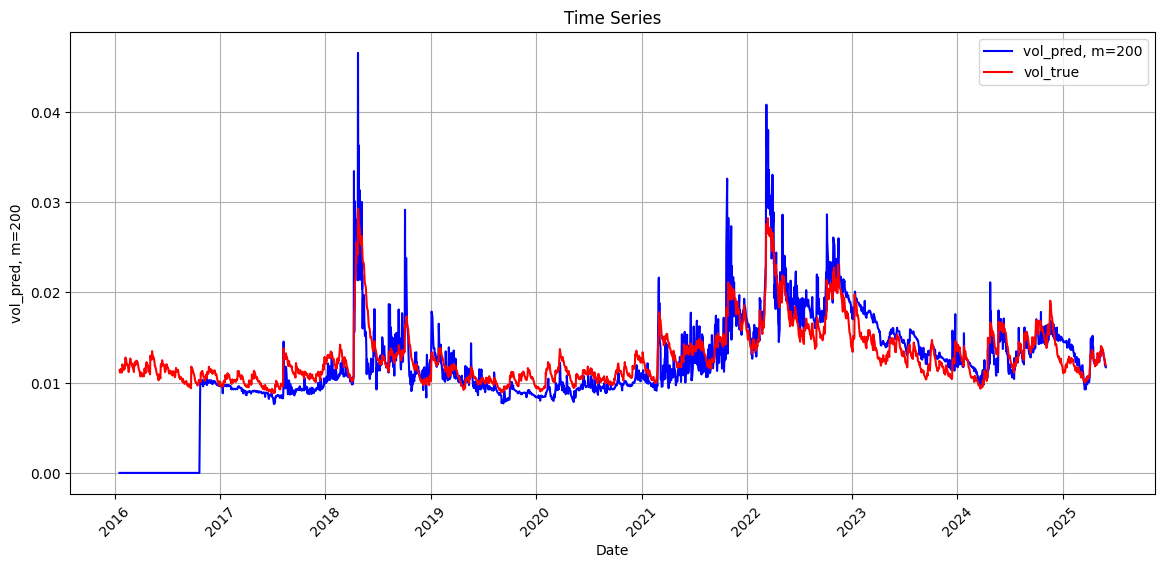

In [25]:
for i, context_window_length in enumerate([10, 30, 100, 200]):
    print(f'{i+1}/{4}')
    vols_pred = [0]*context_window_length
    for i in tqdm(range(context_window_length, df.shape[0])):
        model = arch_model(df['al_lme_prices_log_returns'][i-context_window_length:i], vol='Garch', p=2, q=2, dist='normal', mean='constant', rescale=False)
        res = model.fit(disp='off')
        volatility = res.conditional_volatility
        forecast = res.forecast(horizon=1)
        next_volatility = np.sqrt(forecast.variance.values[-1 ,0])
        vols_pred.append(next_volatility)

    model = arch_model(df['al_lme_prices_log_returns'], vol='Garch', p=1, q=1, dist='normal', mean='constant', rescale=False)
    res = model.fit(disp='off')
    vols_true = res.conditional_volatility

    ax = line_plot(df['date'], vols_pred, f'vol_pred, m={context_window_length}',show=False)
    _ = line_plot(df['date'], vols_true, 'vol_true', linecolor='red', ax=ax, show=True)

  0%|          | 0/2415 [00:00<?, ?it/s]

  6%|▋         | 151/2415 [00:02<00:29, 76.31it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 12%|█▏        | 287/2415 [00:04<00:40, 52.33it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 18%|█▊        | 443/2415 [00:07<00:31, 63.60it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directio

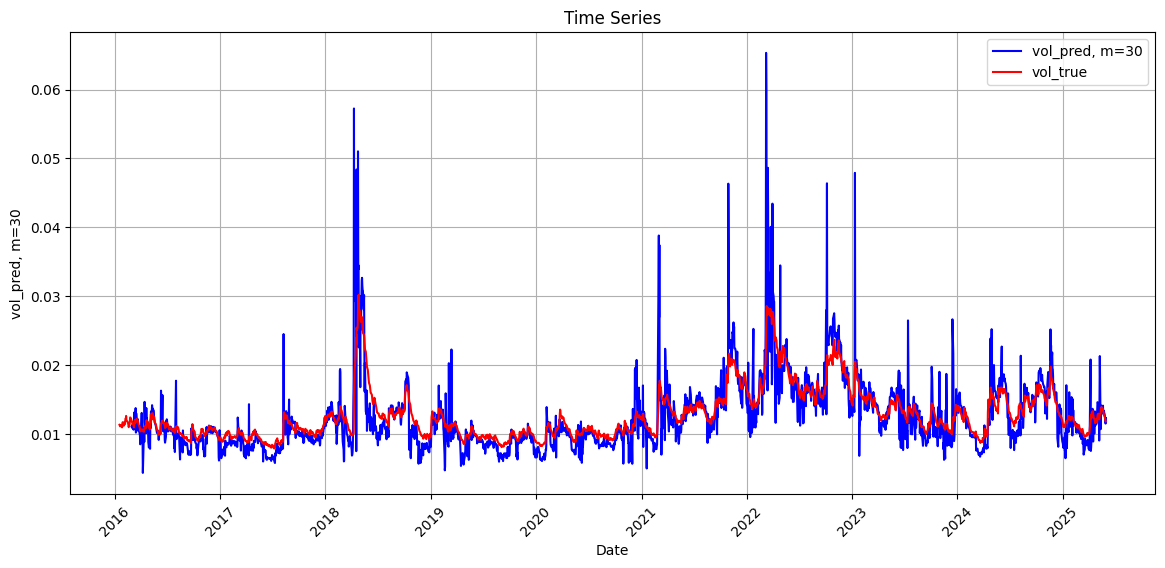

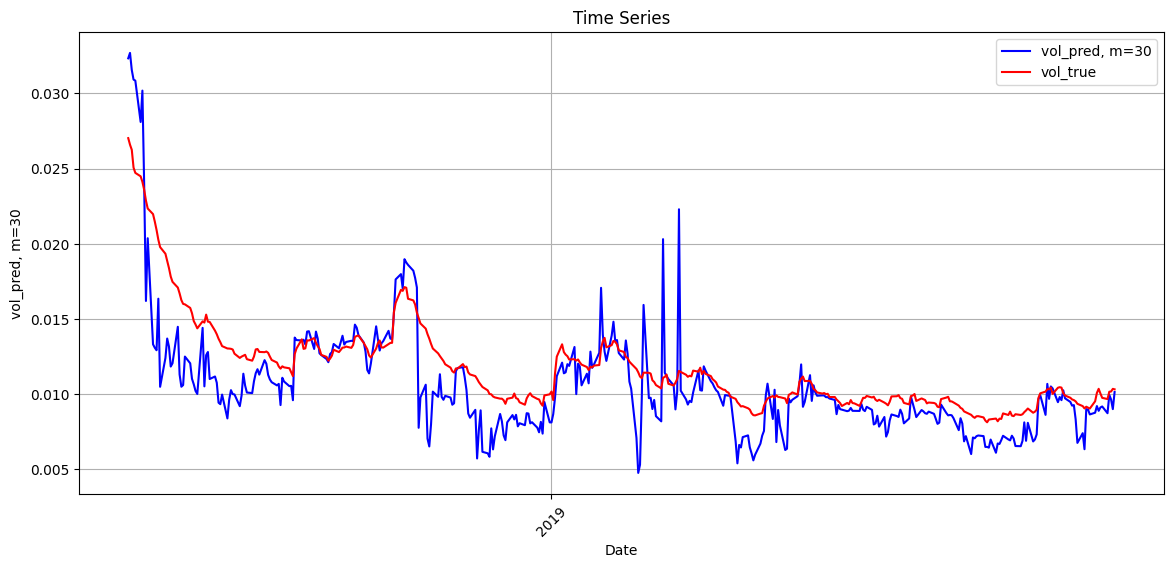

In [31]:
for i, context_window_length in enumerate([10, 30, 100, 200]):
    print(f'{i+1}/{4}')
    vols_pred = [0]*context_window_length
    for i in tqdm(range(context_window_length, df.shape[0])):
        model = arch_model(df['al_lme_prices_log_returns'][i-context_window_length:i], vol='Garch', p=5, q=5, dist='normal', mean='constant', rescale=False)
        res = model.fit(disp='off')
        volatility = res.conditional_volatility
        forecast = res.forecast(horizon=1)
        next_volatility = np.sqrt(forecast.variance.values[-1 ,0])
        vols_pred.append(next_volatility)

    model = arch_model(df['al_lme_prices_log_returns'], vol='Garch', p=1, q=1, dist='normal', mean='constant', rescale=False)
    res = model.fit(disp='off')
    vols_true = res.conditional_volatility

    ax = line_plot(df['date'], vols_pred, f'vol_pred, m={context_window_length}',show=False)
    _ = line_plot(df['date'], vols_true, 'vol_true', linecolor='red', ax=ax, show=True)


1/4


  0%|          | 4/2435 [00:00<01:04, 37.74it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
  0%|          | 12/2435 [00:00<01:22, 29.29it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
  1%|          | 23/2435 [00:00<01:24, 28.42it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is

2/4


  0%|          | 0/2415 [00:00<?, ?it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
  2%|▏         | 39/2415 [00:01<01:15, 31.42it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scip

3/4


  5%|▍         | 116/2345 [00:03<00:58, 37.80it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
  6%|▌         | 131/2345 [00:03<00:59, 37.05it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 10%|▉         | 230/2345 [00:07<01:24, 25.07it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The messag

4/4


 11%|█         | 249/2245 [00:06<01:01, 32.62it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 14%|█▍        | 319/2245 [00:09<00:57, 33.43it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 14%|█▍        | 323/2245 [00:09<01:00, 31.53it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The messag

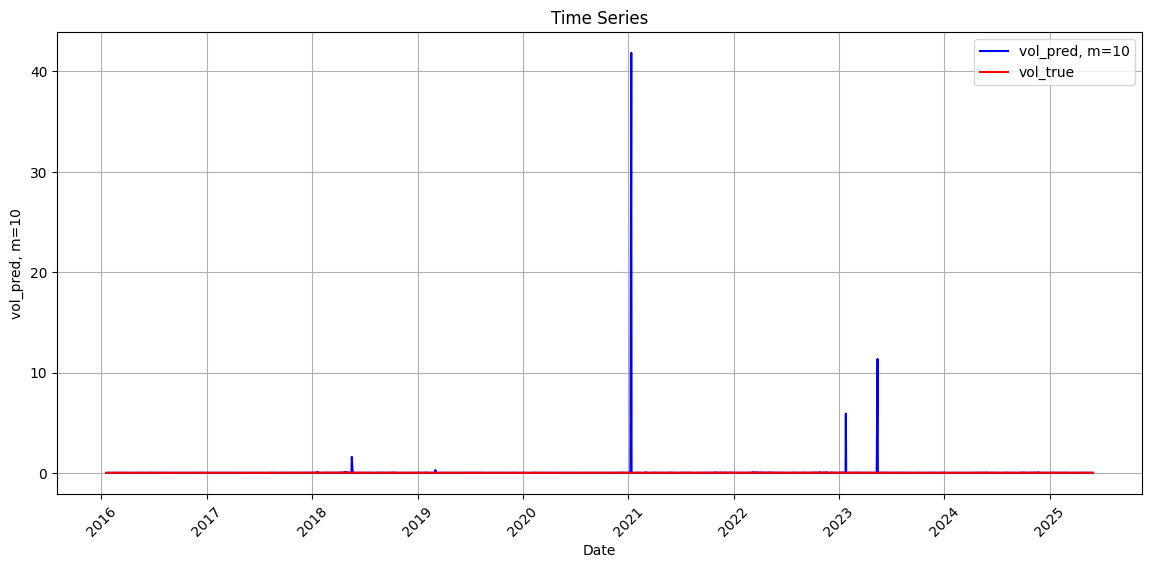

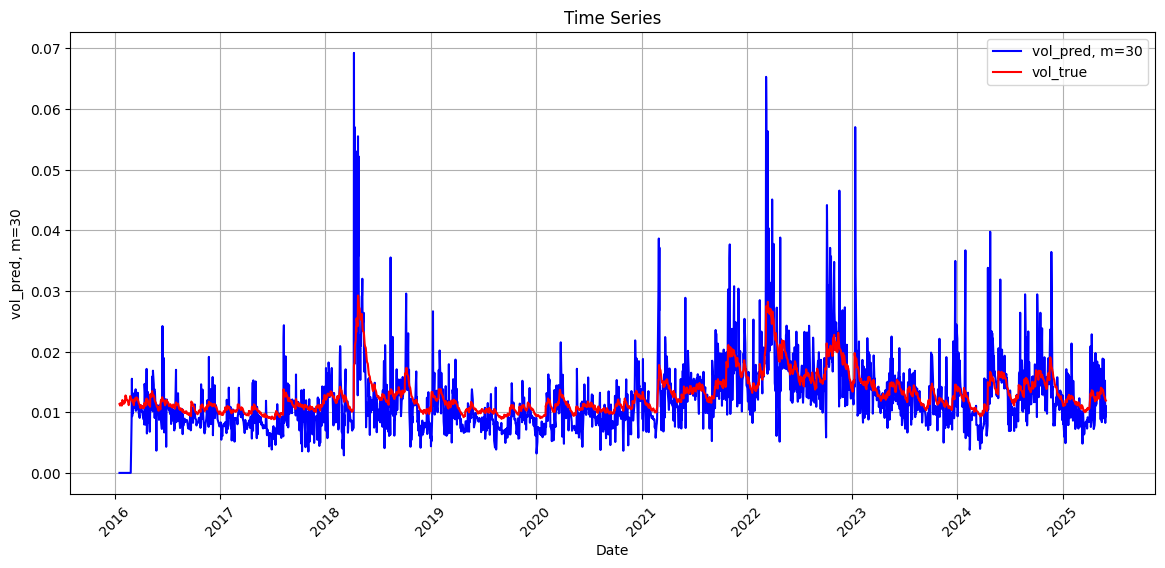

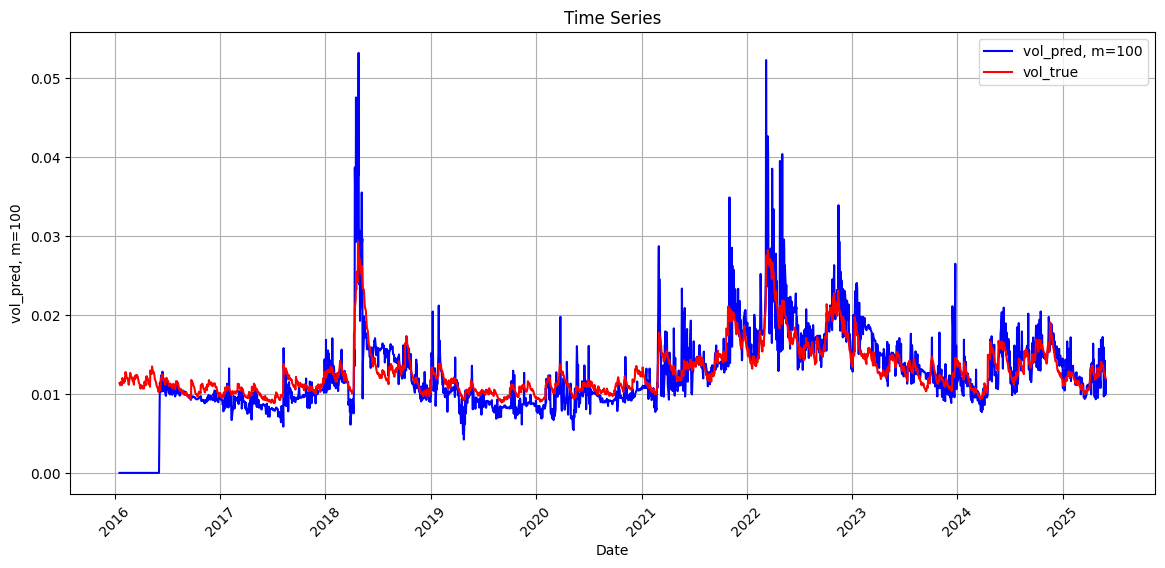

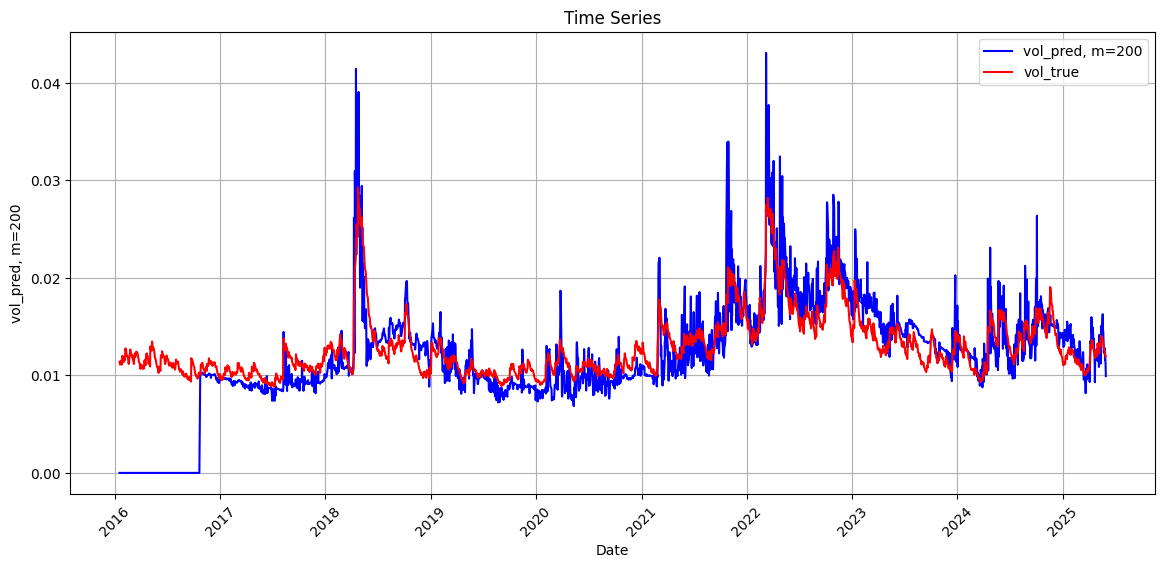

In [32]:
for i, context_window_length in enumerate([10, 30, 100, 200]):
    print(f'{i+1}/{4}')
    vols_pred = [0]*context_window_length
    for i in tqdm(range(context_window_length, df.shape[0])):
        model = arch_model(df['al_lme_prices_log_returns'][i-context_window_length:i], vol='Garch', p=5, q=5, dist='normal', mean='constant', rescale=False)
        res = model.fit(disp='off')
        volatility = res.conditional_volatility
        forecast = res.forecast(horizon=1)
        next_volatility = np.sqrt(forecast.variance.values[-1 ,0])
        vols_pred.append(next_volatility)

    model = arch_model(df['al_lme_prices_log_returns'], vol='Garch', p=1, q=1, dist='normal', mean='constant', rescale=False)
    res = model.fit(disp='off')
    vols_true = res.conditional_volatility

    ax = line_plot(df['date'], vols_pred, f'vol_pred, m={context_window_length}',show=False)
    _ = line_plot(df['date'], vols_true, 'vol_true', linecolor='red', ax=ax, show=True)

In [34]:
vols_pred

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 np.float64(0.010116366153955954),
 np.float64(0.010074422630938117),
 np.float64(0.01022714883999785),
 np.float64(0.010199819091666952),
 np.float64(0.01021062109453086),
 np.float64(0.0102612650863

In [35]:
vols_true

0       0.011363
1       0.011292
2       0.011107
3       0.011257
4       0.011516
          ...   
2440    0.012528
2441    0.012227
2442    0.012181
2443    0.011982
2444    0.011917
Name: cond_vol, Length: 2445, dtype: float64